In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

path_home = Path.home()
print(path_home)

current_folder = Path.cwd()
print(current_folder)

project_folder = os.path.dirname(current_folder)
print(project_folder)

archivo = os.path.join(project_folder, 'data', 'PruebaDS.xlsx')
print(archivo)

df = pd.read_excel(archivo)

print(df.shape)

C:\Users\emers
c:\Users\emers\git_hub\Prueba Tecnica Liquitty\src
c:\Users\emers\git_hub\Prueba Tecnica Liquitty
c:\Users\emers\git_hub\Prueba Tecnica Liquitty\data\PruebaDS.xlsx
(29613, 18)


In [2]:
# Normalizacion de espacios en nombres de las columnas, practica usada siempre

df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

In [3]:
# Tipo de datos para cada columna

print(df.dtypes)

mes                                         object
tipo_documento                              object
identificacion                               int64
genero                                      object
rango_edad_probable                         object
departamento                                object
saldo_capital                              float64
dias_mora                                    int64
banco                                       object
antiguedad_deuda                    datetime64[ns]
pago_mes_anterior                            int64
meses_desde_ultimo_pago                    float64
sin_pago_previo                              int64
contacto_mes_actual                          int64
contacto_mes_anterior                        int64
contacto_ultimos_6meses                      int64
duracion_llamadas_ultimos_6meses             int64
pago                                         int64
dtype: object


In [4]:
# Cantidad de nulos en cada columna

nulos = df.isnull().sum().sort_values(ascending=False)
print(nulos)

meses_desde_ultimo_pago             29135
antiguedad_deuda                    21097
genero                              14656
departamento                         7789
rango_edad_probable                  7378
mes                                     0
tipo_documento                          0
identificacion                          0
dias_mora                               0
saldo_capital                           0
banco                                   0
pago_mes_anterior                       0
sin_pago_previo                         0
contacto_mes_actual                     0
contacto_mes_anterior                   0
contacto_ultimos_6meses                 0
duracion_llamadas_ultimos_6meses        0
pago                                    0
dtype: int64


In [5]:
# Cantidad de duplicados en cada columna

duplicados = {}

for col in df.columns:
    total = df.shape[0]
    unicos = df[col].nunique(dropna=False)
    duplicados[col] = total - unicos

duplicados_df = (pd.DataFrame.from_dict(duplicados, orient='index', columns=['duplicados']).sort_values('duplicados', ascending=False))
print(duplicados_df)

                                  duplicados
contacto_mes_actual                    29611
contacto_mes_anterior                  29611
sin_pago_previo                        29611
pago_mes_anterior                      29611
contacto_ultimos_6meses                29611
pago                                   29611
tipo_documento                         29609
banco                                  29608
genero                                 29607
meses_desde_ultimo_pago                29604
mes                                    29601
rango_edad_probable                    29586
departamento                           29581
antiguedad_deuda                       28510
duracion_llamadas_ultimos_6meses       27951
dias_mora                              26383
identificacion                          5776
saldo_capital                           4318


In [6]:
# Descripcion de cada variable numerica por eso la T para trasponer la tabla y tener una mejor lectura de cada columna, tenemos estadisticas de promedio, minimo, maximo, media, mediana y moda, desviacion standar etc.

var_numericas = df.describe().T
print(var_numericas)

                                    count                           mean  \
identificacion                    29613.0                  550555.404687   
saldo_capital                     29613.0                 5728032.906225   
dias_mora                         29613.0                    1621.956945   
antiguedad_deuda                     8516  2017-08-27 16:29:32.099577344   
pago_mes_anterior                 29613.0                       0.006956   
meses_desde_ultimo_pago             478.0                       1.874477   
sin_pago_previo                   29613.0                       0.983858   
contacto_mes_actual               29613.0                       0.102759   
contacto_mes_anterior             29613.0                       0.103401   
contacto_ultimos_6meses           29613.0                       0.174653   
duracion_llamadas_ultimos_6meses  29613.0                     109.742681   
pago                              29613.0                       0.017661   

           

In [7]:
# Aca la descripcion de cada variable categorica no numerica, por lo que solo incluimos formato object y de igual maneera transponemos la tabla para mayor legibilidad

var_categ = df.describe(include='object').T
print(var_categ)

                     count unique         top   freq
mes                  29613     12     2025-07   4270
tipo_documento       29613      4           C  29436
genero               14957      5           M   5965
rango_edad_probable  22235     26       36-40   3018
departamento         21824     31   BOGOTA DC   8383
banco                29613      5  davivienda  14095


In [8]:
# Cardinalidad de los valores en las variables categoricas, esto permite definir que valores debemos normalizar, agrupar o excluir para el entrenamiento del modelo

for col in df.select_dtypes(include='object'):
    print(f'{col}')
    print(df[col].value_counts().head(8))

mes
mes
2025-07    4270
2025-11    4051
2025-10    4040
2025-12    3947
2025-08    3013
2025-09    2953
2025-04    1858
2025-06    1847
Name: count, dtype: int64
tipo_documento
tipo_documento
C    29436
E      146
T       19
P       12
Name: count, dtype: int64
genero
genero
M            5965
HOMBRE       3537
F            3373
MUJER        2052
NO APLICA      30
Name: count, dtype: int64
rango_edad_probable
rango_edad_probable
36-40    3018
31-35    2597
25-30    1433
66+      1392
42-45    1370
41-45    1163
46-50    1060
46-49    1017
Name: count, dtype: int64
departamento
departamento
BOGOTA DC          8383
ANTIOQUIA          2037
VALLE DEL CAUCA    1816
ATLANTICO          1500
CUNDINAMARCA       1408
SANTANDER           904
TOLIMA              594
BOLIVAR             575
Name: count, dtype: int64
banco
banco
davivienda    14095
colpatria      9750
bbva           2494
occidente      2358
citibank        916
Name: count, dtype: int64


In [9]:
df['genero'] = (
    df['genero']
    .astype('string')
    .fillna('SIN INFO')
)

print(df['genero'].value_counts())



genero
SIN INFO     14656
M             5965
HOMBRE        3537
F             3373
MUJER         2052
NO APLICA       30
Name: count, dtype: Int64


In [10]:
# Calcular la antiguedad en dias de la deuda normalizando este dato a algo medible

df['antiguedad_deuda'] = pd.to_datetime(
    df['antiguedad_deuda'],
    errors='coerce'
)

fecha_hoy = pd.Timestamp.today().normalize()

df['antiguedad_deuda_dias'] = (
    fecha_hoy - df['antiguedad_deuda']
).dt.days

df.loc[df['antiguedad_deuda_dias'] < 0, 'antiguedad_deuda_dias'] = 0

df[['antiguedad_deuda', 'antiguedad_deuda_dias']].tail(5)

,antiguedad_deuda,antiguedad_deuda_dias
29608,NaT,NaN
29609,NaT,NaN
29610,2018-03-28,2895.0
29611,2014-03-10,4374.0
29612,2018-06-28,2803.0


In [11]:
# Nos permite encontrar variables que contienen datos en formato fecha

var_fechas = df.select_dtypes(include='datetime')
print(var_fechas.head(10))

  antiguedad_deuda
0              NaT
1       2017-10-21
2              NaT
3              NaT
4              NaT
5              NaT
6              NaT
7              NaT
8              NaT
9              NaT


In [12]:
# De acuerdo a la descripcion realizada anteiormente, en las siguientes columnas tenemos minimos de 0 y maximos de 1 por lo que se entiende que es una columna binaria, donde 1 es relacion positiva y 0 negativa. 

binarias = [
    'pago_mes_anterior',
    'sin_pago_previo',
    'contacto_mes_actual',
    'contacto_mes_anterior',
    'contacto_ultimos_6meses',
    'duracion_llamadas_ultimos_6meses',
    'pago'
]

df[binarias] = df[binarias].astype('int8')

In [13]:
# Este parte identifica cuántos valores atípicos (outliers) tiene cada variable numérica, excluyendo las binarias, usando el método del rango intercuartílico (IQR).
#   
num_cols = df.select_dtypes(include='number').columns.difference(binarias)

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(f'{col}: {outliers.shape[0]} outliers')

antiguedad_deuda_dias: 1428 outliers
dias_mora: 56 outliers
identificacion: 0 outliers
meses_desde_ultimo_pago: 34 outliers
saldo_capital: 3336 outliers


Axes(0.125,0.11;0.775x0.77)


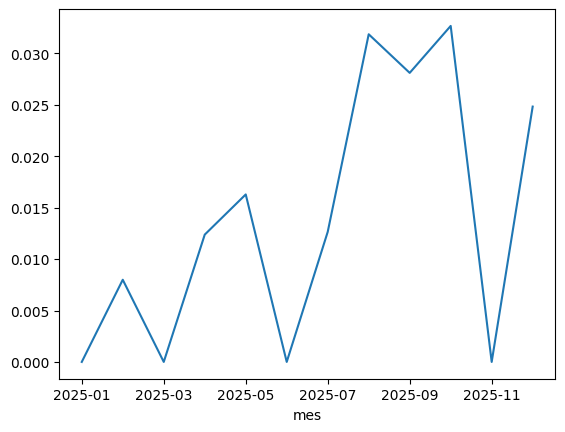

In [14]:
# Revisar la distribucion del pago pra cada mes

distribucion_pago = df.groupby('mes')['pago'].mean().plot()
print(distribucion_pago)


In [15]:

num_cols = df.select_dtypes(include='number').columns
num_cols = num_cols.drop('identificacion', errors='ignore')

df_num = df[num_cols]
print("Variables numéricas usadas en correlación:")
df_num.columns


Variables numéricas usadas en correlación:


Index(['saldo_capital', 'dias_mora', 'pago_mes_anterior',
       'meses_desde_ultimo_pago', 'sin_pago_previo', 'contacto_mes_actual',
       'contacto_mes_anterior', 'contacto_ultimos_6meses',
       'duracion_llamadas_ultimos_6meses', 'pago', 'antiguedad_deuda_dias'],
      dtype='object')

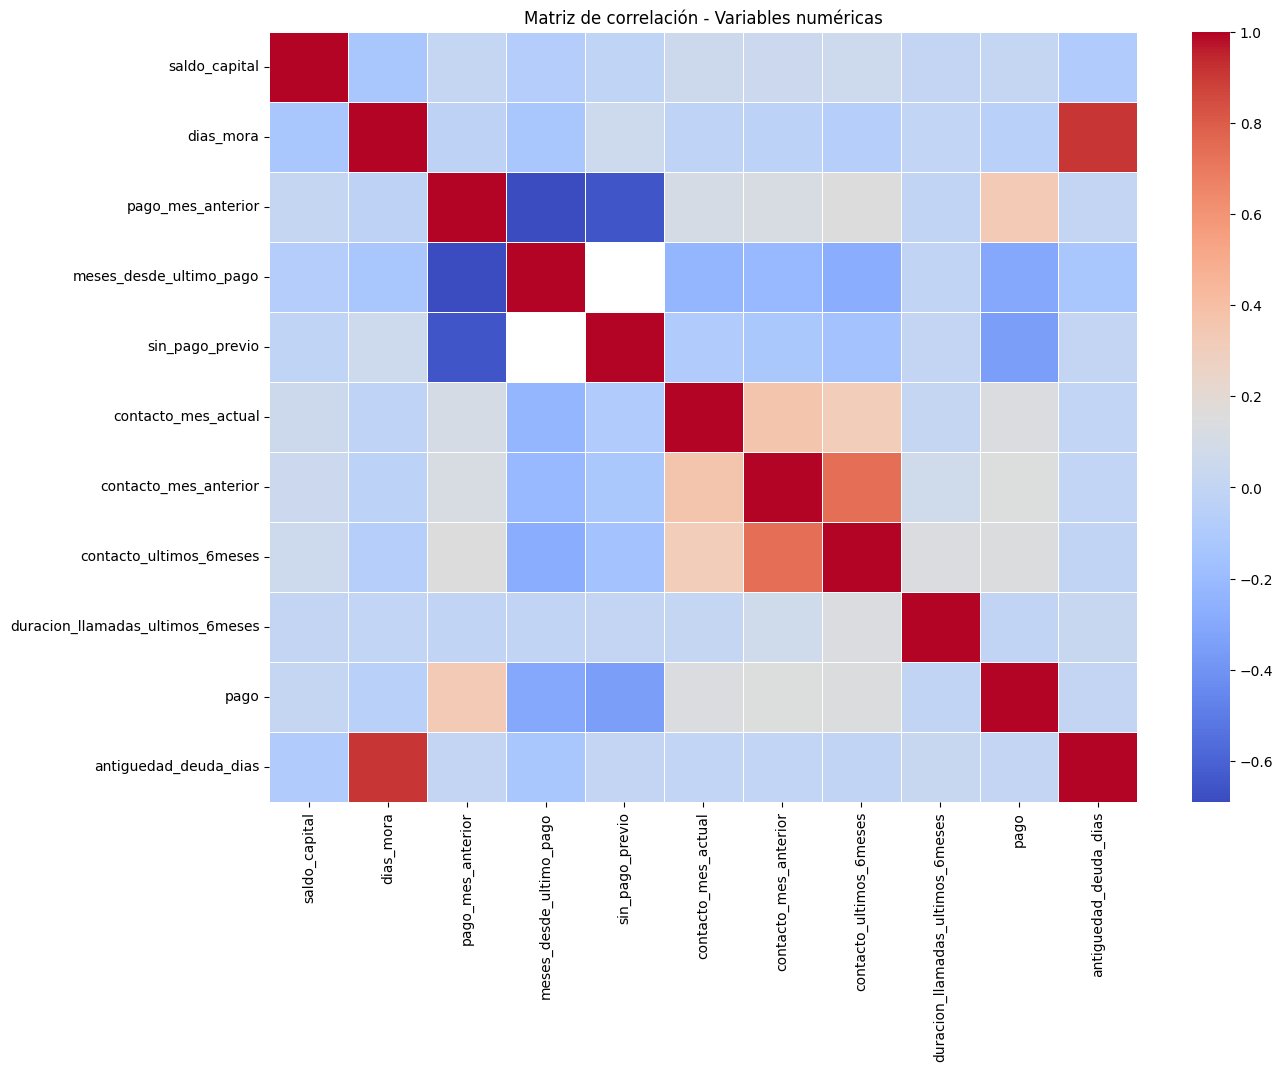

In [16]:
corr_matrix = df_num.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)
plt.title('Matriz de correlación - Variables numéricas')
plt.show()


In [17]:
corr_target = (
    df_num.corr()['pago']
    .sort_values(ascending=False)
)

corr_target


pago                                1.000000
pago_mes_anterior                   0.331170
contacto_mes_anterior               0.148969
contacto_ultimos_6meses             0.143598
contacto_mes_actual                 0.139532
saldo_capital                       0.010193
antiguedad_deuda_dias               0.004181
duracion_llamadas_ultimos_6meses   -0.005679
dias_mora                          -0.055268
meses_desde_ultimo_pago            -0.301946
sin_pago_previo                    -0.351053
Name: pago, dtype: float64

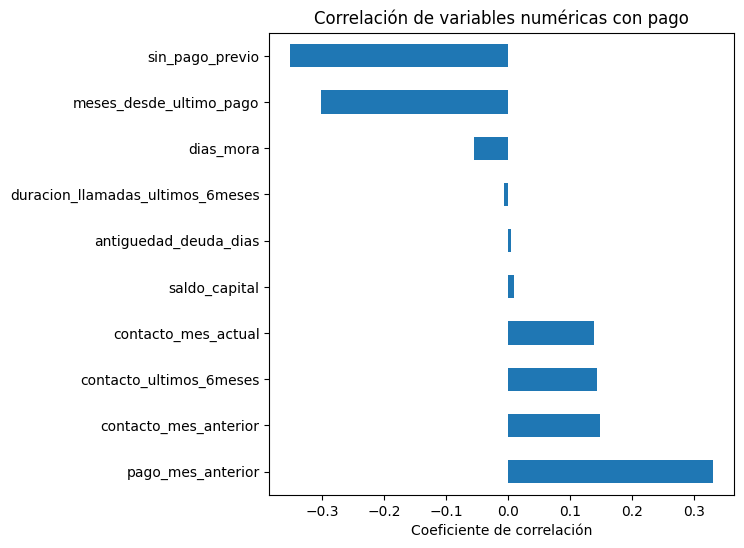

In [18]:
plt.figure(figsize=(6, 6))
corr_target.drop('pago').plot(kind='barh')
plt.title('Correlación de variables numéricas con pago')
plt.xlabel('Coeficiente de correlación')
plt.show()


In [19]:
cat_cols = df.select_dtypes(exclude='number').columns
cat_cols = cat_cols.drop('pago', errors='ignore')

print("Variables categóricas analizadas:")
cat_cols

Variables categóricas analizadas:


Index(['mes', 'tipo_documento', 'genero', 'rango_edad_probable',
       'departamento', 'banco', 'antiguedad_deuda'],
      dtype='object')

In [20]:
for col in cat_cols:
    print(f"\n📌 {col}")
    tasa_pago = (
        df.groupby(col)['pago']
        .mean()
        .sort_values(ascending=False)
    )
    print(tasa_pago)



📌 mes
mes
2025-10    0.032673
2025-08    0.031862
2025-09    0.028107
2025-12    0.024829
2025-05    0.016287
2025-07    0.012646
2025-04    0.012379
2025-02    0.007991
2025-03    0.000000
2025-01    0.000000
2025-06    0.000000
2025-11    0.000000
Name: pago, dtype: float64

📌 tipo_documento
tipo_documento
C    0.017733
E    0.006849
P    0.000000
T    0.000000
Name: pago, dtype: float64

📌 genero
genero
F            0.038245
M            0.019614
SIN INFO     0.015011
HOMBRE       0.011026
MUJER        0.008772
NO APLICA    0.000000
Name: pago, dtype: float64

📌 rango_edad_probable
rango_edad_probable
42-45        0.037956
38-41        0.035714
46-49        0.035398
30-33        0.031933
18-25        0.030303
34-37        0.028668
50-53        0.028571
26-29        0.021739
54-57        0.020086
62-65        0.019518
36-40        0.018555
31-35        0.018098
46-50        0.016981
25-30        0.016050
22-25        0.016000
58-61        0.014885
61-65        0.014085
66+          

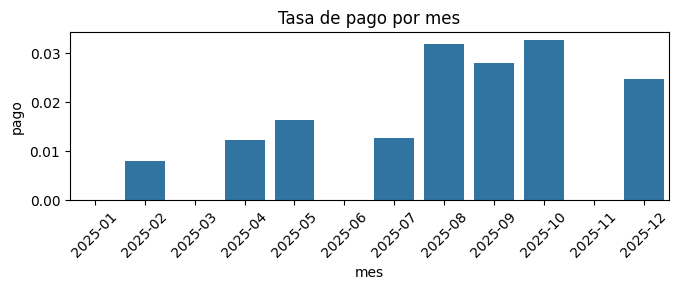

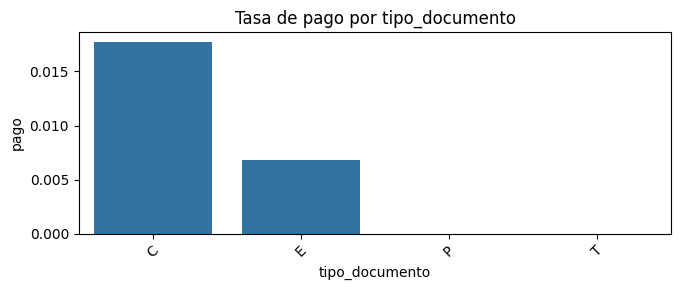

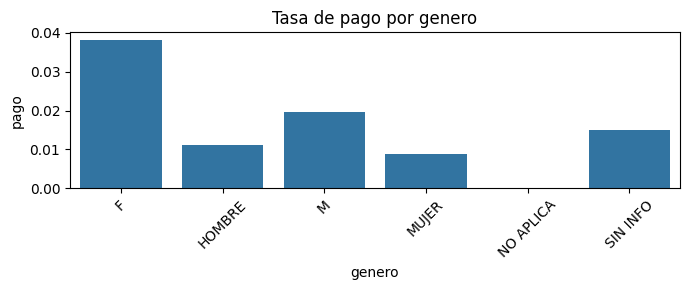

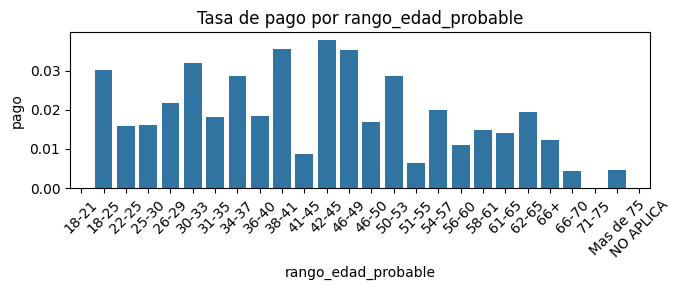

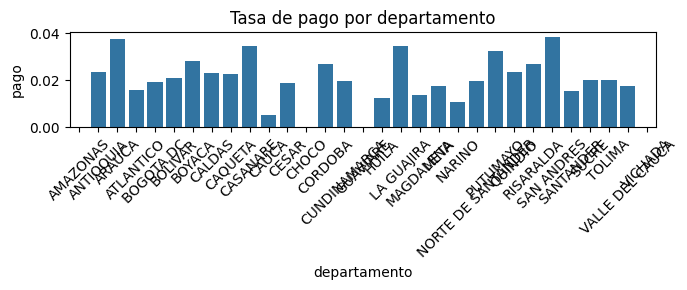

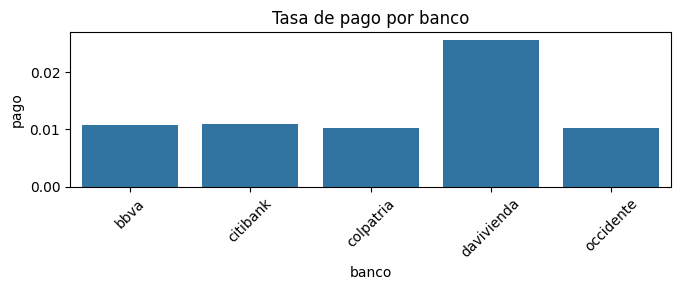

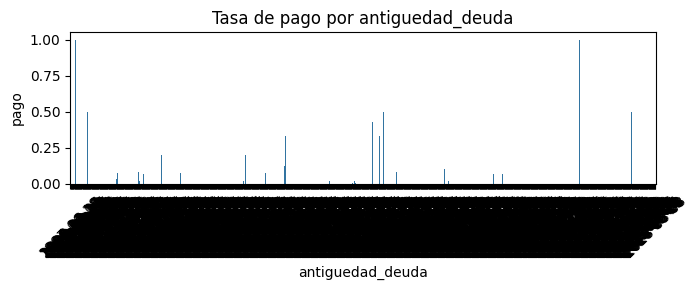

In [21]:
for col in cat_cols:
    tasa_pago = df.groupby(col)['pago'].mean().reset_index()

    plt.figure(figsize=(7, 3))
    sns.barplot(data=tasa_pago, x=col, y='pago')
    plt.title(f'Tasa de pago por {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Modelo Predictivo de Probabilidad de Pago

---

## 1. Definición del Problema

El objetivo del presente modelo es estimar la probabilidad de que un cliente realice el pago en el siguiente período mensual, a partir de información histórica y variables explicativas de carácter sociodemográfico, financiero y de gestión.

Desde la perspectiva de aprendizaje automático, se trata de un problema de:

- Tipo: Clasificación binaria supervisada  
- Variable objetivo:
  - 1 → Cliente paga en el período siguiente
  - 0 → Cliente no paga en el período siguiente

El modelo aprenderá patrones históricos que permitan anticipar el comportamiento futuro de pago.

---

## 2. Contexto de Aplicación

El modelo será utilizado como sistema de scoring mensual para la planificación de campañas de cobranza.

Para cada cliente activo en un mes determinado, se generará una probabilidad estimada de pago que permitirá:

- Priorizar esfuerzos de gestión
- Optimizar asignación de recursos
- Diseñar estrategias diferenciadas por segmento de riesgo

Ejemplo conceptual:

Cliente: Juan Pérez  
ID: 12345  
Mes a predecir: Enero 2026  

El modelo entregará un score probabilístico asociado a ese período.

---

## 3. Supuestos sobre la Estructura de los Datos

El dataset presenta una estructura longitudinal:

- Cada fila representa un cliente en un mes específico.
- Existen aproximadamente 23.837 clientes únicos.
- Un mismo cliente puede aparecer múltiples veces en distintos períodos.
- Algunos clientes presentan una única observación (nuevos).
- Otros presentan entre 3 y 4 registros históricos.

### Implicaciones metodológicas

1. Se implementará validación temporal (time-based split) para evitar fuga de información.
2. Se construirán variables históricas agregadas por cliente.
3. Se respetará la secuencia cronológica en entrenamiento y validación.

### Tratamiento de valores nulos estructurales

Variables como `meses_desde_ultimo_pago` pueden contener valores nulos no aleatorios.

En lugar de imputar arbitrariamente, se:

- Recodificarán como categoría explícita (`sin_info`).
- Crearàn variables indicadoras para capturar su señal predictiva.

---

## 4. Supuesto de Desbalance de Clases

El análisis exploratorio evidencia un desbalance significativo entre la clase negativa (no pago) y la clase positiva (pago).

Sin corrección, el modelo tendería a optimizar la predicción de la clase mayoritaria.

### Estrategia de mitigación

- Aplicación de técnicas de sobremuestreo sintético (ej. SMOTE) en el conjunto de entrenamiento.
- Evaluación mediante métricas robustas ante desbalance:

  - ROC-AUC  
  - PR-AUC  
  - F1-Score  
  - Recall de la clase positiva  

El objetivo es garantizar capacidad predictiva adecuada sobre la clase de interés.

---

## 5. Supuesto de Multicolinealidad

Se evaluará la existencia de correlaciones significativas entre variables explicativas mediante:

- Matriz de correlación
- Análisis exploratorio de relaciones lineales

Especial atención a:

- Variables de contacto
- Variables financieras
- Relación entre estas y la variable objetivo

En caso de detectar redundancia significativa:

- Se combinarán variables altamente correlacionadas.
- Se reducirá dimensionalidad conceptual cuando sea pertinente.

---

## 6. Estrategia de Feature Engineering

### 6.1 Tratamiento de Información Faltante

Se crearán variables indicadoras para capturar ausencia estructural de información:

- `sin_historial_pago` → cuando `meses_desde_ultimo_pago` sea nulo.
- `sin_antiguedad_conocida` → cuando `antiguedad_deuda` sea nulo.

Este enfoque preserva la información implícita en la falta del dato.

---

### 6.2 Variables Derivadas

Se construirán variables con mayor capacidad explicativa:

**Ratio de mora**

\[
ratio\_mora\_saldo = \frac{dias\_mora}{saldo\_capital}
\]

**Contacto total**

Suma agregada de todas las variables asociadas a intentos o resultados de contacto.

**Pago reciente**

Combinación de:

- `pago_mes_anterior`
- Indicador de ausencia de pago previo

Permite capturar persistencia o inercia conductual.

---

### 6.3 Discretización de Variables Continuas

Con fines de interpretabilidad y robustez:

- `saldo_capital_rango`: bajo, medio, alto, muy alto  
- `dias_mora_categoria`: al día, mora leve, mora grave, crítico  

La discretización se realizará bajo criterios estadísticos y de negocio.

---

### 6.4 Codificación de Variables Categóricas

Se aplicará una estrategia diferenciada según cardinalidad:

- One-Hot Encoding:
  - Variables de baja cardinalidad (ej. género, rango_edad_probable)

- Target Encoding:
  - Variables de alta cardinalidad (ej. departamento, banco)

Esta estrategia busca balancear capacidad predictiva y control de dimensionalidad.

---

## 7. Consideraciones Finales

El modelo propuesto se fundamenta en:

- Validación temporal rigurosa
- Control del desbalance de clases
- Ingeniería de características orientada a negocio
- Evaluación de multicolinealidad
- Enfoque en interpretabilidad y robustez estadística

El propósito final es construir un sistema de scoring sólido, reproducible y alineado con la toma de decisiones estratégicas en procesos de cobranza.